## Data Modelling

In [ ]:
import os # get working directory
import pandas as pd
import numpy as np
import re # regular expression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

### Pre-modelling assessment

In [22]:
hospital_los_train_final = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_train_final.csv")
hospital_los_train_final.head(10)

,ICU_DAYS,NUM_CHRONIC_COND,ORDER_SET_USED,ORDER_TOTAL_CHARGES,X,Y,PATIENT_AGE,ICD9_TARGET,DRG_APR_SEVERITY,OPERATION_COUNT,...,icu_x_severity,visits_x_chronic,icu_x_comorbidity,careteam_x_comorbidity,comorbidity_x_age,age_group_40_54,age_group_55_64,age_group_65_74,age_group_75_84,age_group_85_plus
0,4,2,0,13691,-77.18702,38.773578,64,1,3,0,...,12,2,8,6,128,False,True,False,False,False
1,1,0,1,33790,-77.18702,38.773578,98,1,1,1,...,1,0,0,0,0,False,False,False,False,True
2,0,1,1,17601,-77.18702,38.773578,75,1,2,2,...,0,0,0,25,375,False,False,True,False,False
3,0,1,1,11565,-77.18702,38.773578,81,1,2,0,...,0,4,0,0,0,False,False,False,True,False
4,6,1,1,43357,-77.18702,38.773578,81,0,2,1,...,12,2,12,2,162,False,False,False,True,False
5,7,2,1,37106,-77.18702,38.773578,69,1,3,1,...,21,2,56,40,552,False,False,True,False,False
6,0,1,1,13812,-77.18702,38.773578,87,1,4,1,...,0,2,0,9,261,False,False,False,False,True
7,3,0,1,14853,-77.18702,38.773578,77,1,2,1,...,6,0,9,6,231,False,False,False,True,False
8,3,1,1,27145,-77.18702,38.773578,85,1,3,1,...,9,0,9,9,255,False,False,False,True,False
9,3,1,1,13416,-77.18702,38.773578,76,1,2,0,...,6,2,0,0,0,False,False,False,True,False


In [23]:
hospital_los_test_final = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_final.csv")
hospital_los_test_final.head(10)

,ICU_DAYS,NUM_CHRONIC_COND,ORDER_SET_USED,ORDER_TOTAL_CHARGES,X,Y,PATIENT_AGE,ICD9_TARGET,DRG_APR_SEVERITY,OPERATION_COUNT,...,icu_x_severity,visits_x_chronic,icu_x_comorbidity,careteam_x_comorbidity,comorbidity_x_age,age_group_40_54,age_group_55_64,age_group_65_74,age_group_75_84,age_group_85_plus
0,2,2,0,200,-77.18702,38.773578,64,0,2,0,...,4,30,4,6,128,False,True,False,False,False
1,1,1,1,9027,-77.18702,38.773578,67,1,2,0,...,2,2,0,0,0,False,False,True,False,False
2,3,1,1,10885,-77.18702,38.773578,73,0,2,0,...,6,9,3,1,73,False,False,True,False,False
3,1,1,1,8289,-77.18702,38.773578,92,0,1,1,...,1,1,2,4,184,False,False,False,False,True
4,2,1,1,26815,-77.18702,38.773578,68,1,3,0,...,6,3,0,0,0,False,False,True,False,False
5,0,1,1,16214,-77.18702,38.773578,68,1,4,0,...,0,2,0,20,340,False,False,True,False,False
6,0,2,0,16039,-77.18702,38.773578,76,1,3,1,...,0,0,0,16,304,False,False,False,True,False
7,6,0,1,28490,-77.18702,38.773578,71,1,2,1,...,12,0,18,12,213,False,False,True,False,False
8,2,1,1,21391,-77.18702,38.773578,82,0,3,1,...,6,1,8,16,328,False,False,False,True,False
9,6,0,1,31061,-77.18702,38.773578,77,1,3,0,...,18,0,12,10,154,False,False,False,True,False


In [ ]:
# confirm no missing values and the breakdown of data types
print(hospital_los_train_final.dtypes.value_counts())
print(hospital_los_train_final.isnull().sum().sum(), hospital_los_test_final.isnull().sum().sum())  # should both be 0

bool       48
int64      24
float64    10
Name: count, dtype: int64
0 0


In [5]:
corr_matrix = hospital_los_train_final.drop(columns=['ADMIT_LOS']).corr()
high_corr = corr_matrix.where((corr_matrix.abs() > 0.85) & (corr_matrix.abs() < 1.0))
high_corr_pairs = high_corr.stack().reset_index()
high_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
print(high_corr_pairs.sort_values('correlation', key=abs, ascending=False))

                           feature_1                         feature_2  \
6                  COMORBIDITY_INDEX                 comorbidity_x_age   
21                 comorbidity_x_age                 COMORBIDITY_INDEX   
15                    icu_x_severity                          ICU_DAYS   
0                           ICU_DAYS                    icu_x_severity   
4                  COMORBIDITY_INDEX                    chronic_burden   
7                     chronic_burden                 COMORBIDITY_INDEX   
8                     chronic_burden                 comorbidity_x_age   
22                 comorbidity_x_age                    chronic_burden   
19            careteam_x_comorbidity                 COMORBIDITY_INDEX   
5                  COMORBIDITY_INDEX            careteam_x_comorbidity   
18                 icu_x_comorbidity                    icu_x_severity   
16                    icu_x_severity                 icu_x_comorbidity   
10                  dist_to_hospital  

In [13]:
# Drop chronic_burden - confirmed exact linear combination of NUM_CHRONIC_COND + COMORBIDITY_INDEX,
# which caused perfect multicollinearity (R²=1.0, divide-by-zero in VIF)
X = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'chronic_burden'])
X = X.select_dtypes(include=['number', 'bool'])
X = X.astype({col: 'int64' for col in X.select_dtypes(include='bool').columns})

X_sample = X.sample(n=10000, random_state=42)
vif_data = pd.DataFrame()
vif_data['feature'] = X_sample.columns
vif_data['VIF'] = [variance_inflation_factor(X_sample.values, i) for i in range(X_sample.shape[1])]
print(vif_data.sort_values('VIF', ascending=False).head(15))

                              feature          VIF
4                                   X  6039.909109
67                HOSPITAL_target_enc  3534.265310
5                                   Y  1055.270404
6                         PATIENT_AGE   552.484377
69   DIAGNOSIS_SUBCAT_CODE_target_enc   437.782866
68                DX_GROUP_target_enc   410.601958
18      DIAGNOSIS_ICD_CODE_target_enc   162.235444
59                       STATECODE_FL   109.712167
11                  COMORBIDITY_INDEX    81.090266
21            DRG_APR_CODE_target_enc    77.867611
78                    age_group_75_84    72.409681
46  DISCHARGED_TO_ROUTINE DSCHG, HOME    66.864078
74                  comorbidity_x_age    66.313457
79                  age_group_85_plus    63.580095
20             MS_DRG_CODE_target_enc    56.098942


In [ ]:
# create a log-transformed column for ADMIT_LOS
hospital_los_train_final['ADMIT_LOS_log'] = np.log1p(hospital_los_train_final['ADMIT_LOS'])

In [25]:
# Final feature trim based on correlation/VIF findings:
# drop features that are largely redundant with another feature already kept in the set

# chronic_burden is an exact linear combination of NUM_CHRONIC_COND + COMORBIDITY_INDEX (caused VIF divide-by-zero)
# MS_DRG_CODE/DRG_APR_CODE/DX_GROUP/DIAGNOSIS_SUBCAT_CODE target encodings overlap heavily with DIAGNOSIS_ICD_CODE (same diagnostic hierarchy)
# STATECODE/REGION dummies and dist_to_hospital overlap heavily with X/Y coordinates (same geography signal)
# age_group dummies are a coarser restatement of PATIENT_AGE, already in the feature set

cols_to_drop = [
    'chronic_burden',
    'MS_DRG_CODE_target_enc', 'DRG_APR_CODE_target_enc', 
    'DX_GROUP_target_enc', 'DIAGNOSIS_SUBCAT_CODE_target_enc',
    'STATECODE_AR', 'STATECODE_FL', 'STATECODE_GA', 'STATECODE_IL', 
    'STATECODE_MO', 'STATECODE_MS', 'STATECODE_TN', 'STATECODE_TX', 'STATECODE_VA',
    'REGION_Region 2', 'REGION_Region 3', 'REGION_Region 4', 'REGION_Region 5',
    'REGION_Region 6', 'REGION_Region 7', 'REGION_Region 8', 'REGION_Region 9',
    'REGION_Region 10', 'REGION_Region 11',
    'dist_to_hospital',
    'age_group_40_54', 'age_group_55_64', 'age_group_65_74', 'age_group_75_84', 'age_group_85_plus'
]

hospital_los_train_final = hospital_los_train_final.drop(columns=cols_to_drop)
hospital_los_test_final = hospital_los_test_final.drop(columns=[c for c in cols_to_drop if c in hospital_los_test_final.columns])

print(hospital_los_train_final.shape, hospital_los_test_final.shape)
print(hospital_los_train_final.columns.tolist())
print(hospital_los_test_final.columns.tolist())

(100000, 53) (15000, 51)
['ICU_DAYS', 'NUM_CHRONIC_COND', 'ORDER_SET_USED', 'ORDER_TOTAL_CHARGES', 'X', 'Y', 'PATIENT_AGE', 'ICD9_TARGET', 'DRG_APR_SEVERITY', 'OPERATION_COUNT', 'MONITORING_HOURS', 'COMORBIDITY_INDEX', 'CARE_TEAM_SIZE', 'ADMIT_MTH', 'NUM_VISITS', 'ADMIT_LOS', 'had_procedure', 'STANDARD_ORDERS_USED', 'high_severity_flag', 'DIAGNOSIS_ICD_CODE_target_enc', 'PROCEDURE_ICD_CODE_target_enc', 'geo_cluster', 'DEPARTMENT_GENERAL SURG', 'DEPARTMENT_HEART', 'DEPARTMENT_NEUROSCIENCES', 'DEPARTMENT_ONCOLOGY', 'DEPARTMENT_PSYCH', 'DEPARTMENT_PULMONARY', 'DEPARTMENT_TRANSPLANT', 'DEPARTMENT_Unknown', 'DEPARTMENT_WOMENS', 'GENDER_M', 'RACE_CD_Others', 'RACE_CD_White', 'DIAGNOSIS_GROUP_CHF', 'DIAGNOSIS_GROUP_COPD', 'DISCHARGED_TO_CHG TO LTAC', 'DISCHARGED_TO_HOME HEALTH AGENCY', 'DISCHARGED_TO_HOSPICE (HOME)', 'DISCHARGED_TO_HOSPICE - MEDICAL INP', 'DISCHARGED_TO_INTERMEDIATE CARE', 'DISCHARGED_TO_OTHER ACUTE HOSP', 'DISCHARGED_TO_OTHER DEATH', 'DISCHARGED_TO_REHAB HOSPITAL', 'DISCHARG

In [ ]:
# train and validation split
X = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'ADMIT_LOS_log'])
y = hospital_los_train_final['ADMIT_LOS_log']  # using log-transformed target given the 3.26 skew

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(80000, 51) (20000, 51)


## Data Modelling

In [ ]:
# fit Ridge, Lasso, and Random Forest on the train/validation split
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# use xgboost technique
xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, 
                          random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [42]:
# predict on validation set, reverse log1p transform to get predictions in actual days
ridge_val_preds = np.expm1(ridge_model.predict(X_val))
lasso_val_preds = np.expm1(lasso_model.predict(X_val))
rf_val_preds = np.expm1(rf_model.predict(X_val))
xgb_val_preds = np.expm1(xgb_model.predict(X_val))

# y_val was also log-transformed - reverse it too for fair comparison in raw-day space
y_val_raw = np.expm1(y_val)

In [43]:
def evaluate_model(y_true, y_pred, model_name="model"):
    """Computes RMSE, MAE, R² in raw-day space for a given model's validation predictions"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

results = []
results.append(evaluate_model(y_val_raw, ridge_val_preds, "Ridge"))
results.append(evaluate_model(y_val_raw, lasso_val_preds, "Lasso"))
results.append(evaluate_model(y_val_raw, rf_val_preds, "Random Forest"))
results.append(evaluate_model(y_val_raw, xgb_val_preds, "XGBoost"))

hospital_los_prediction = pd.DataFrame(results).sort_values('rmse')
print(hospital_los_prediction)

Ridge: RMSE=2.303, MAE=1.454, R²=0.702
Lasso: RMSE=3.310, MAE=2.052, R²=0.384
Random Forest: RMSE=2.131, MAE=1.384, R²=0.745
XGBoost: RMSE=2.049, MAE=1.335, R²=0.764
           model      rmse       mae        r2
3        XGBoost  2.048828  1.335279  0.764132
2  Random Forest  2.131178  1.384450  0.744790
0          Ridge  2.303337  1.454453  0.701892
1          Lasso  3.309876  2.052143  0.384424


In [51]:
print((lasso_model.coef_ == 0).sum(), "out of", len(lasso_model.coef_), "coefficients zeroed")

48 out of 51 coefficients zeroed


In [ ]:
# hyperparameter tuning for XGBoost via RandomizedSearchCV
# keeping the original default xgb_model untouched for comparison against the tuned version
param_distributions = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV RMSE (log-scale):", -xgb_search.best_score_)

xgb_tuned_model = xgb_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV RMSE (log-scale): 0.2482451850274864


In [ ]:
# uses Poisson technique with xgb
y_train_raw = np.expm1(y_train)

xgb_poisson = XGBRegressor(objective='count:poisson', n_estimators=300, max_depth=6,
                            learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
                            min_child_weight=5, random_state=42, n_jobs=-1)
xgb_poisson.fit(X_train, y_train_raw)

,objective,'count:poisson'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [72]:
xgb_poisson_val_preds = xgb_poisson.predict(X_val)  # already raw scale, no expm1 needed

results = [r for r in results if r['model'] != 'XGBoost (Poisson)']
results.append(evaluate_model(y_val_raw, xgb_poisson_val_preds, "XGBoost (Poisson)"))

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

XGBoost (Poisson): RMSE=2.033, MAE=1.344, R²=0.768
               model      rmse       mae        r2
0  XGBoost (Poisson)  2.033026  1.344066  0.767756
1    XGBoost (tuned)  2.043905  1.333553  0.765264
2            XGBoost  2.048828  1.335279  0.764132
3      Random Forest  2.131178  1.384450  0.744790
4              Ridge  2.303337  1.454453  0.701892
5              Lasso  3.309876  2.052143  0.384424


In [74]:
# poisson fine tuned
param_distributions_poisson = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'max_delta_step': [0, 1, 5, 10]  # Poisson-specific stabilization parameter
}

xgb_poisson_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective='count:poisson', random_state=42, n_jobs=-1),
    param_distributions=param_distributions_poisson,
    n_iter=30,
    scoring='neg_root_mean_squared_error',  # scored directly on raw scale since Poisson predicts raw counts
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_poisson_search.fit(X_train, y_train_raw)

print("Best params:", xgb_poisson_search.best_params_)
print("Best CV RMSE (raw scale):", -xgb_poisson_search.best_score_)

xgb_poisson_tuned = xgb_poisson_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 10, 'max_depth': 5, 'max_delta_step': 1, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE (raw scale): 1.9924804792170605


In [75]:
xgb_poisson_tuned_preds = xgb_poisson_tuned.predict(X_val)

results = [r for r in results if r['model'] != 'XGBoost (Poisson tuned)']
results.append(evaluate_model(y_val_raw, xgb_poisson_tuned_preds, "XGBoost (Poisson tuned)"))
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
print(results_df)

XGBoost (Poisson tuned): RMSE=2.019, MAE=1.338, R²=0.771
                     model      rmse       mae        r2
0  XGBoost (Poisson tuned)  2.019250  1.337642  0.770893
1        XGBoost (Poisson)  2.033026  1.344066  0.767756
2          XGBoost (tuned)  2.043905  1.333553  0.765264
3                  XGBoost  2.048828  1.335279  0.764132
4            Random Forest  2.131178  1.384450  0.744790
5                    Ridge  2.303337  1.454453  0.701892
6                    Lasso  3.309876  2.052143  0.384424


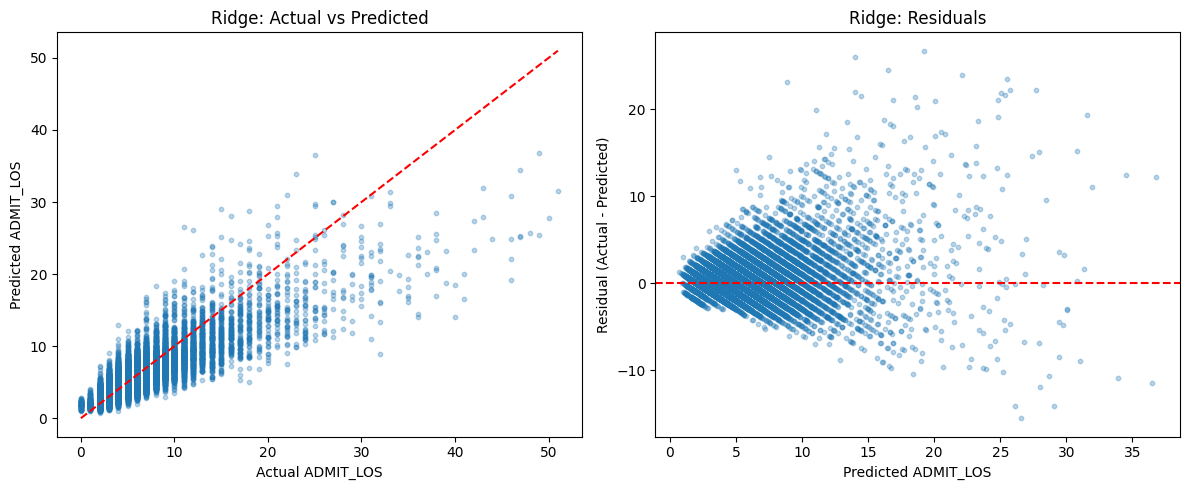

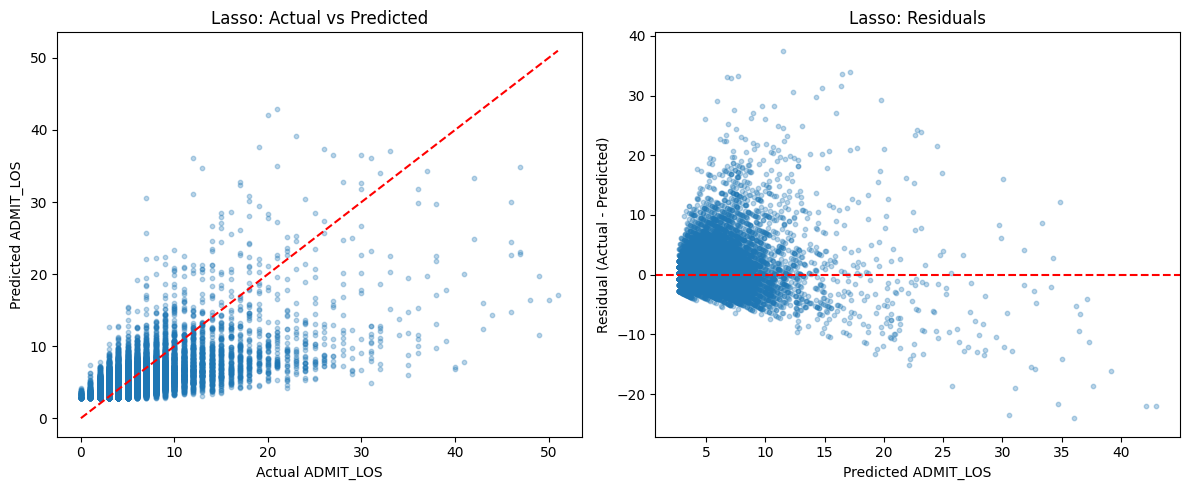

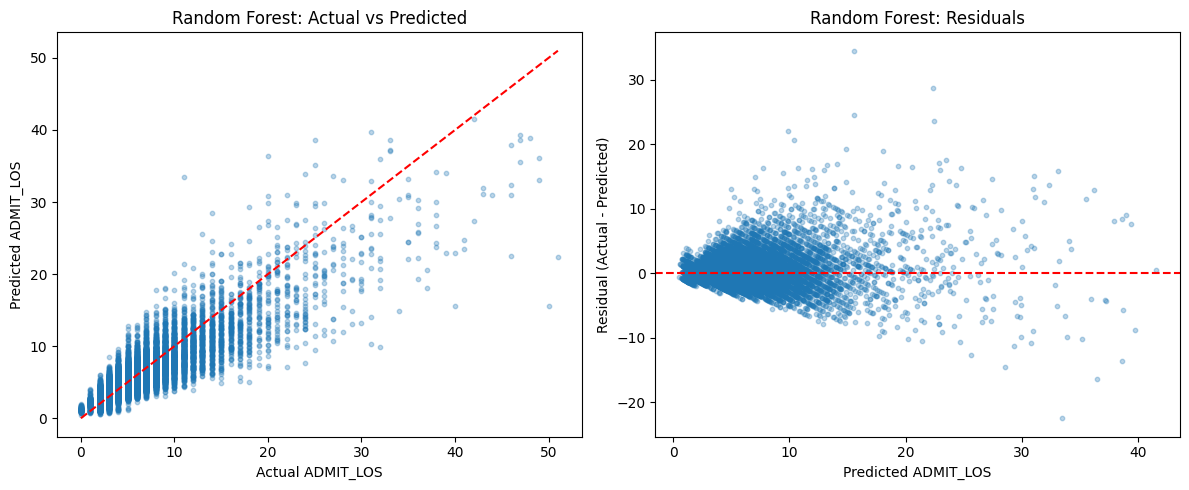

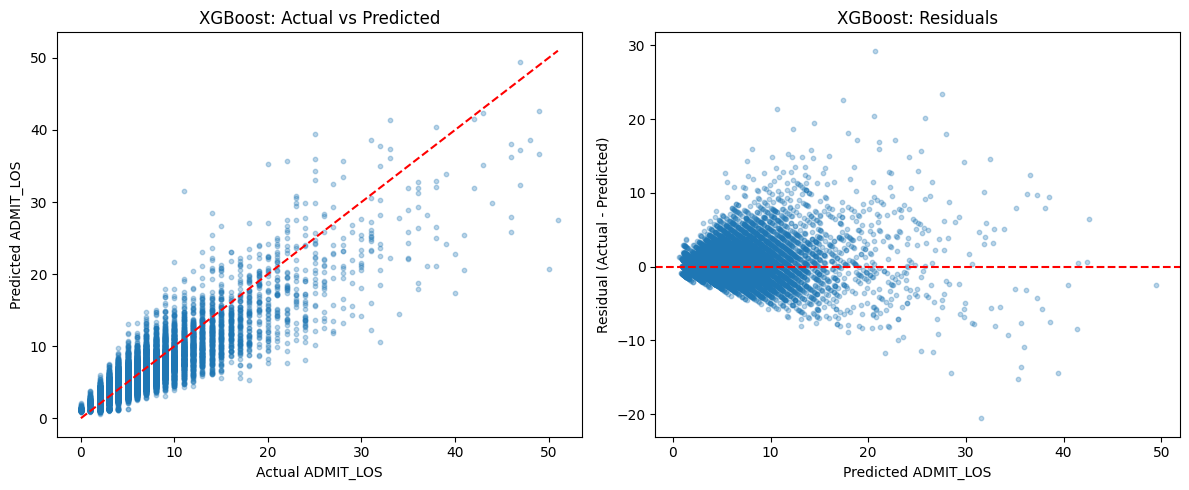

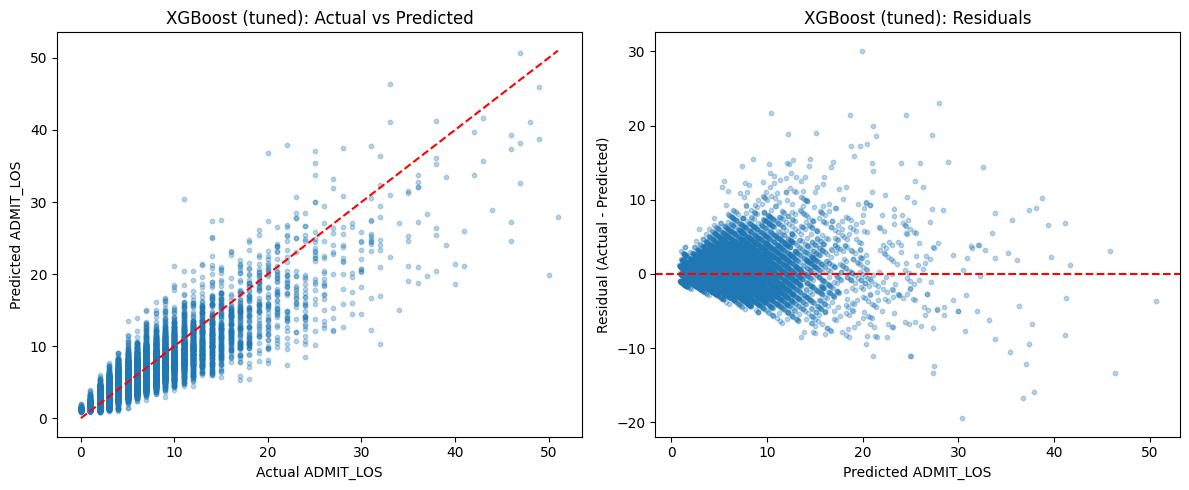

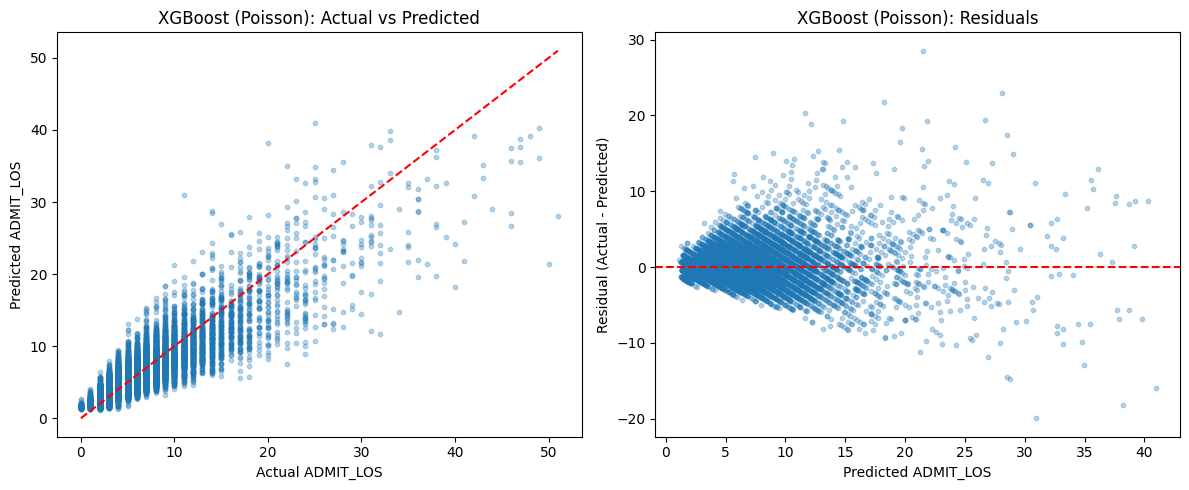

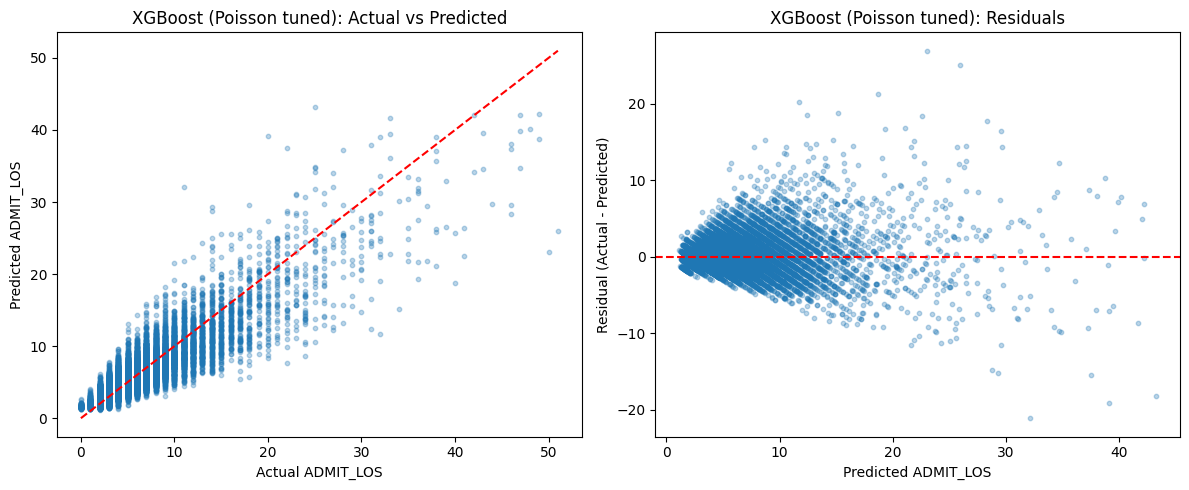

In [76]:
# Actual vs predicted and residual plots for visual model assessment
def plot_diagnostics(y_true, y_pred, model_name="model"):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0].set_xlabel('Actual ADMIT_LOS')
    axes[0].set_ylabel('Predicted ADMIT_LOS')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')
    
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=10)
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted ADMIT_LOS')
    axes[1].set_ylabel('Residual (Actual - Predicted)')
    axes[1].set_title(f'{model_name}: Residuals')
    
    plt.tight_layout()
    plt.show()

plot_diagnostics(y_val_raw, ridge_val_preds, "Ridge")
plot_diagnostics(y_val_raw, lasso_val_preds, "Lasso")
plot_diagnostics(y_val_raw, rf_val_preds, "Random Forest")
plot_diagnostics(y_val_raw, xgb_val_preds, "XGBoost")
plot_diagnostics(y_val_raw, xgb_tuned_val_preds, "XGBoost (tuned)")
plot_diagnostics(y_val_raw, xgb_poisson_val_preds, "XGBoost (Poisson)")
plot_diagnostics(y_val_raw, xgb_poisson_tuned_preds, "XGBoost (Poisson tuned)")

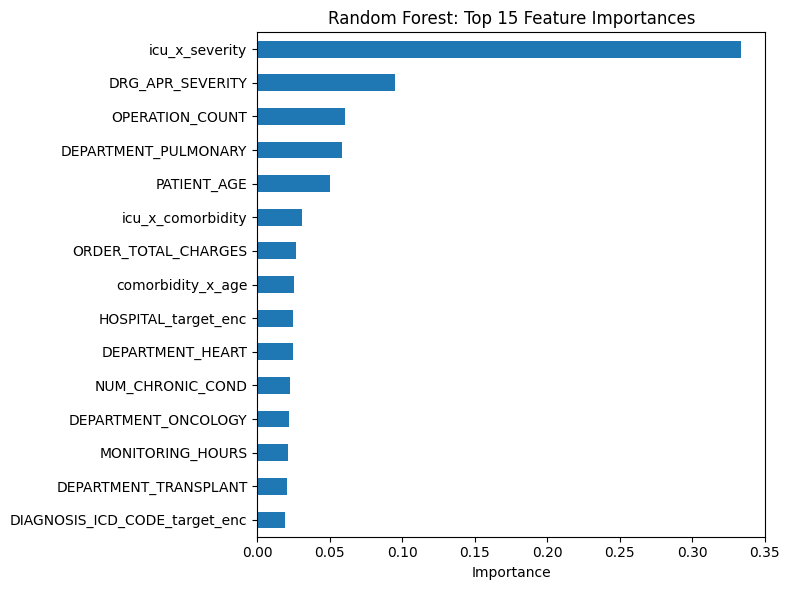

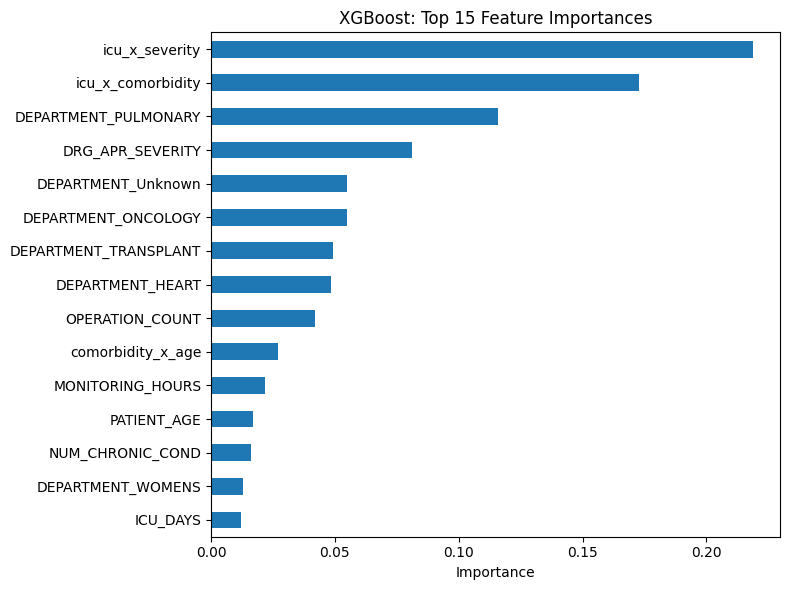

In [77]:
def plot_feature_importance(model, feature_names, model_name="model", top_n=15):
    """Shows top N most influential features for a fitted tree-based model"""
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(8, 6))
    top_features.sort_values().plot(kind='barh')
    plt.title(f'{model_name}: Top {top_n} Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    return top_features

rf_importance = plot_feature_importance(rf_model, X_train.columns, "Random Forest")
xgb_importance = plot_feature_importance(xgb_model, X_train.columns, "XGBoost")

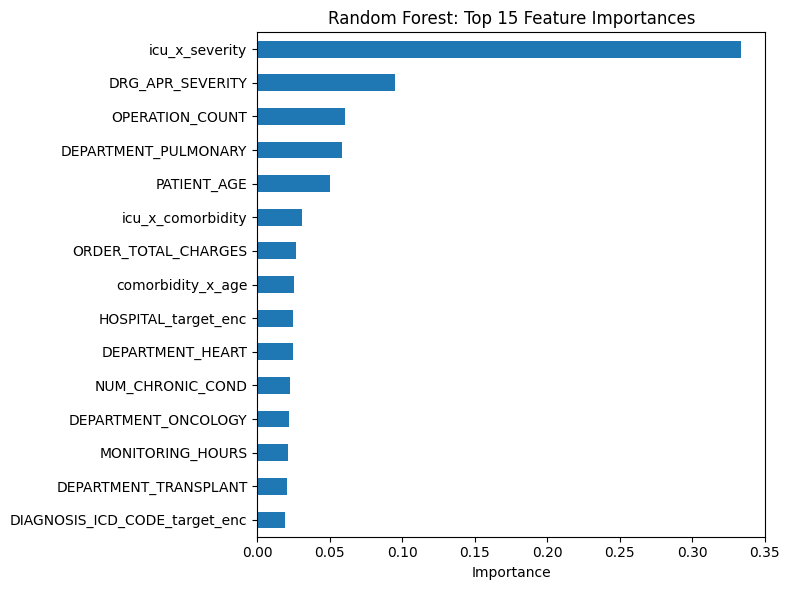

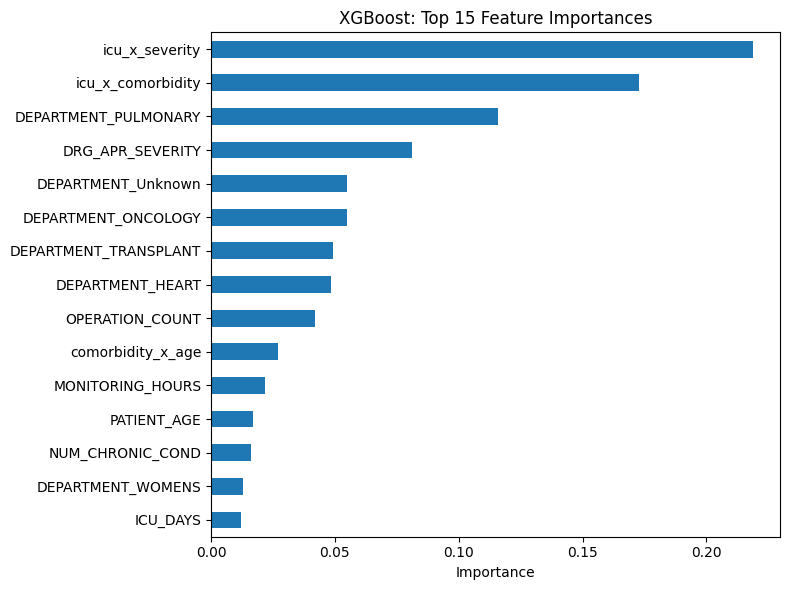

Best model: XGBoost (Poisson tuned)


In [79]:
# Feature importance - keep as reference/diagnostic, not tied to final model selection
rf_importance = plot_feature_importance(rf_model, X_train.columns, "Random Forest")
xgb_importance = plot_feature_importance(xgb_model, X_train.columns, "XGBoost")

# Select best model based on lowest RMSE from validation comparison
best_model_name = results_df.iloc[0]['model']
print(f"Best model: {best_model_name}")

X_full = hospital_los_train_final.drop(columns=['ADMIT_LOS', 'ADMIT_LOS_log'])
y_full_log = hospital_los_train_final['ADMIT_LOS_log']
y_full_raw = hospital_los_train_final['ADMIT_LOS']

In [83]:
test_original = pd.read_csv('/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_transformed.csv')
test_encounter_keys = test_original['ENCOUNTER_KEY']

In [84]:
# Map model name to a fresh, untrained instance with its tuned hyperparameters,
# plus which target scale (log vs raw) it needs to be trained on
model_config = {
    'Ridge': {'model': Ridge(alpha=1.0), 'target': 'log'},
    'Lasso': {'model': Lasso(alpha=1.0), 'target': 'log'},
    'Random Forest': {'model': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost': {'model': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost (tuned)': {'model': XGBRegressor(**xgb_search.best_params_, random_state=42, n_jobs=-1), 'target': 'log'},
    'XGBoost (Poisson)': {'model': XGBRegressor(objective='count:poisson', n_estimators=300, max_depth=6,
                                                  learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
                                                  min_child_weight=5, random_state=42, n_jobs=-1), 'target': 'raw'},
    'XGBoost (Poisson tuned)': {'model': XGBRegressor(objective='count:poisson', **xgb_poisson_search.best_params_,
                                                        random_state=42, n_jobs=-1), 'target': 'raw'}
}

config = model_config[best_model_name]
final_model = config['model']

if config['target'] == 'log':
    final_model.fit(X_full, y_full_log)
    test_preds_raw = np.expm1(final_model.predict(hospital_los_test_final))
else:
    final_model.fit(X_full, y_full_raw)
    test_preds_raw = final_model.predict(hospital_los_test_final)  # already raw scale, no expm1

test_preds = np.clip(np.round(test_preds_raw), a_min=0, a_max=None)

submission = pd.DataFrame({
    'ENCOUNTER_KEY': test_encounter_keys,
    'ADMIT_LOS': test_preds.astype(int)
})

submission.to_csv('/workspaces/myfolder/project/sasviya_challenge_2026/data/submission.csv', index=False)
print(submission.head())
print(submission.shape)

   ENCOUNTER_KEY  ADMIT_LOS
0      300103958          4
1      300111093          3
2      300102017          4
3      300108959          3
4      300114930          4
(15000, 2)
